# Fine-tune CRAFT Text Detection Model on Custom Dataset

This notebook demonstrates how to fine-tune the CRAFT text detection model on a custom dataset with bounding box annotations. Follow the steps below to prepare your data, set up the model, and train for improved text detection performance.

In [ ]:
# Clone CRAFT-pytorch
!git clone https://github.com/clovaai/CRAFT-pytorch.git

# Clone EasyOCR
!git clone https://github.com/JaidedAI/EasyOCR.git

## 1. Import Required Libraries
Import PyTorch, torchvision, numpy, PIL, and other necessary libraries. Ensure CRAFT and EasyOCR modules are available.

In [1]:
# Import Required Libraries
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Add CRAFT and EasyOCR to the path if not installed as packages
_craft_path_candidates = [
    os.path.abspath('/kaggle/input/craft-finetune/CRAFT-finetune/CRAFT-pytorch'),
    os.path.abspath(os.path.join(os.getcwd(), 'CRAFT-pytorch'))
]
_easyocr_path_candidates = [
    os.path.abspath('/kaggle/input/craft-finetune/CRAFT-finetune/EasyOCR'),
    os.path.abspath(os.path.join(os.getcwd(), 'EasyOCR'))
]
for candidate in _craft_path_candidates:
    if candidate not in sys.path and os.path.exists(candidate):
        sys.path.append(candidate)
for candidate in _easyocr_path_candidates:
    if candidate not in sys.path and os.path.exists(candidate):
        sys.path.append(candidate)

# Try importing CRAFT and EasyOCR modules
try:
    from craft import CRAFT
    print('CRAFT module loaded.')
except ImportError:
    print('CRAFT module not found. Please check the path.')

try:
    import easyocr
    print('EasyOCR module loaded.')
except ImportError:
    print('EasyOCR module not found. Please check the path.')

CRAFT module loaded.
EasyOCR module loaded.


## 2. Set Up Paths and Hyperparameters
Define paths for the dataset, annotation files, and output directories. Set hyperparameters such as batch size, learning rate, number of epochs, and device (CPU/GPU).

In [2]:
# Set up paths and hyperparameters
_kaggle_root = '/kaggle/input/craft-finetune/CRAFT-finetune'
_local_root = os.path.abspath(os.path.join(os.getcwd(), 'synthetic_finetune_data'))
pages_kaggle = os.path.join(_kaggle_root, 'synthetic_finetune_data', 'pages')
pages_local = os.path.join(_local_root, 'pages')
bboxes_kaggle = os.path.join(_kaggle_root, 'synthetic_finetune_data', 'bboxes', 'words')
bboxes_local = os.path.join(_local_root, 'bboxes', 'words')
DATA_DIR = pages_kaggle if os.path.exists(pages_kaggle) else pages_local
BBOX_DIR = bboxes_kaggle if os.path.exists(bboxes_kaggle) else bboxes_local
if not os.path.exists(DATA_DIR) or not os.path.exists(BBOX_DIR):
    raise FileNotFoundError("Could not locate image or bbox directories. Please update DATA_DIR and BBOX_DIR paths.")
OUTPUT_DIR = 'output_craft_finetune'  # Directory to save outputs
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 1
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")
print(f"Images from: {DATA_DIR}")
print(f"BBoxes from: {BBOX_DIR}")

Using device: cuda
Images from: c:\Users\sarth\Documents\RenAIssance\RenAIssance_SyntheticImageGeneration_Saarthak_Gupta\synthetic_finetune_data\pages
BBoxes from: c:\Users\sarth\Documents\RenAIssance\RenAIssance_SyntheticImageGeneration_Saarthak_Gupta\synthetic_finetune_data\bboxes\words


## 3. Load and Preprocess Dataset
Implement a custom PyTorch Dataset class to load images and parse bounding box annotations. Apply necessary image transformations and augmentations.

In [4]:
# --- Required imports (add these at top of your file) ---
import os
import cv2
import numpy as np
import pyclipper
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# --- Helper functions ------------------------------------------------------

def _to_quadrilateral(box):
    box = np.array(box, dtype=np.float32).flatten()
    if box.size == 4:
        x1, y1, x2, y2 = box
        quad = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.float32)
    elif box.size >= 8:
        quad = box.reshape(-1, 2)[:4].astype(np.float32)
    else:
        raise ValueError(f"Unexpected box format with {box.size} values: {box}")
    return quad

def _clip_polygon(quad, width, height):
    quad[:, 0] = np.clip(quad[:, 0], 0, width - 1)
    quad[:, 1] = np.clip(quad[:, 1], 0, height - 1)
    return quad

def shrink_polygon_pyclipper(polygon, shrink_ratio):
    """
    polygon: iterable of (x,y)
    shrink_ratio: fraction in (0,1) controlling inset amount relative to min(box_dim)
    Returns None if shrinking fails or results empty.
    """
    poly = [(float(x), float(y)) for x, y in polygon]
    xs = [p[0] for p in poly]; ys = [p[1] for p in poly]
    w = max(xs) - min(xs); h = max(ys) - min(ys)
    if w <= 0 or h <= 0:
        return None
    # offset distance (negative to inset)
    offset = -shrink_ratio * min(w, h)
    pco = pyclipper.PyclipperOffset()
    pco.AddPath(poly, pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)
    try:
        shrunk = pco.Execute(offset)
    except Exception:
        return None
    if not shrunk:
        return None
    # choose polygon with largest area
    best = max(shrunk, key=lambda s: abs(pyclipper.Area(s)))
    return [(int(round(x)), int(round(y))) for x, y in best]

def fill_poly(mask, poly_pts, value=1.0):
    if poly_pts is None or len(poly_pts) < 3:
        return
    pts = np.array([poly_pts], dtype=np.int32)
    cv2.fillPoly(mask, pts, float(value))

import math

def make_char_boxes_from_word_poly_rotated(poly_rect, text=None,
                                           avg_char_px=20, max_chars_for_split=50,
                                           min_char_width_px=3):
    """
    Returns a list of character boxes (each as 4 pts) splitting the word polygon along
    its long axis. poly_rect is 4 pts (x,y). If text is provided, uses len(text) as
    char count; otherwise estimates char count = round(word_length_px / avg_char_px),
    clamped to [1, max_chars_for_split].
    This works for rotated rects (non-axis aligned) by using the minAreaRect and slicing
    along its long side.
    """
    poly = np.array(poly_rect, dtype=np.float32).reshape(-1, 2)
    # Get minimal area rect to find orientation and size
    rect = cv2.minAreaRect(poly)  # ((cx,cy), (w,h), angle)
    (cx, cy), (Wrect, Hrect), angle = rect
    # Use the longer side as the word axis
    if Wrect >= Hrect:
        word_len = Wrect
        word_h = Hrect
        long_side = 'w'
    else:
        word_len = Hrect
        word_h = Wrect
        long_side = 'h'

    # decide number of chars
    if isinstance(text, str) and len(text) > 0:
        n_chars = len(text)
    else:
        n_chars = max(1, int(round(word_len / float(avg_char_px))))
    n_chars = min(max(1, n_chars), max_chars_for_split)

    # If only 1 char -> return poly rect as single char box (4 pts)
    if n_chars == 1:
        return [poly_rect]

    # Build the rotation matrix to map points into rect coordinate frame
    angle_rad = -math.radians(angle)  # negative to rotate points so rect axis align with x/y
    cos_a = math.cos(angle_rad); sin_a = math.sin(angle_rad)
    R = np.array([[cos_a, -sin_a], [sin_a, cos_a]], dtype=np.float32)
    center = np.array([cx, cy], dtype=np.float32)

    # Transform polygon pts to rect-aligned coordinates
    pts = (poly - center) @ R.T  # now rect is axis aligned centered at (0,0)
    # The rect extents in this frame:
    half_w = Wrect / 2.0
    half_h = Hrect / 2.0

    # We'll slice along x if long_side == 'w' (which is now axis-aligned x)
    # Generate n_chars vertical slice boundaries along [-half_w, +half_w]
    xs = np.linspace(-half_w, half_w, n_chars + 1)

    char_boxes = []
    for i in range(n_chars):
        x0 = xs[i]; x1 = xs[i + 1]
        # quad in rect-coordinates (clockwise)
        rect_quad = np.array([
            [x0, -half_h],
            [x1, -half_h],
            [x1, half_h],
            [x0, half_h]
        ], dtype=np.float32)
        # transform quad back: inverse rotation and add center
        invR = R.T
        world_quad = (rect_quad @ invR) + center
        # round to floats (keep float for pyclipper later)
        char_boxes.append([(float(p[0]), float(p[1])) for p in world_quad.tolist()])

    # filter out boxes that are too narrow in pixel width
    filtered = []
    for b in char_boxes:
        xs = [p[0] for p in b]; box_w = max(xs) - min(xs)
        if box_w >= min_char_width_px:
            filtered.append(b)
    if len(filtered) == 0:
        # fallback: return original poly
        return [poly_rect]
    return filtered


def draw_affinity_from_chars_improved(aff_map, word_poly, text=None,
                                      avg_char_px=18, char_shrink=0.4,
                                      min_char_width=2, max_chars_for_split=100):
    """
    Generates affinity map by:
      - splitting word_poly into pseudo-char polys (rotated-aware),
      - shrinking each char polygon with pyclipper,
      - drawing narrow quads between consecutive shrunk char cores into aff_map.
    Writes max combination into aff_map in [0,1].
    """
    H, W = aff_map.shape

    # Get char boxes (rotated-aware)
    char_boxes = make_char_boxes_from_word_poly_rotated(word_poly, text=text,
                                                        avg_char_px=avg_char_px,
                                                        max_chars_for_split=max_chars_for_split,
                                                        min_char_width_px=min_char_width)
    # Shrink each char with pyclipper
    shrunk_chars = []
    for cb in char_boxes:
        s = shrink_polygon_pyclipper(cb, char_shrink)
        if s:
            shrunk_chars.append(np.array(s, dtype=np.float32))
        else:
            shrunk_chars.append(np.array(cb, dtype=np.float32))

    # If only one shrunk char: fallback to distance-transform gaussian on that area
    if len(shrunk_chars) <= 1:
        if len(shrunk_chars) == 1:
            s = shrunk_chars[0]
            x_min = max(int(np.floor(s[:, 0].min())) - 1, 0)
            y_min = max(int(np.floor(s[:, 1].min())) - 1, 0)
            x_max = min(int(np.ceil(s[:, 0].max())) + 1, W)
            y_max = min(int(np.ceil(s[:, 1].max())) + 1, H)
            if x_max > x_min and y_max > y_min:
                mask = np.zeros((y_max - y_min, x_max - x_min), dtype=np.uint8)
                shifted = (s - np.array([x_min, y_min])).astype(np.int32)
                cv2.fillPoly(mask, [shifted], 255)
                if cv2.countNonZero(mask) > 0:
                    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
                    if dist.max() > 0:
                        dn = dist / (dist.max() + 1e-6)
                        g = np.exp(-((1.0 - dn) ** 2) / (2 * (0.45 ** 2 + 1e-6)))
                        g = (g - g.min()) / (g.max() - g.min() + 1e-6)
                        aff_map[y_min:y_max, x_min:x_max] = np.maximum(aff_map[y_min:y_max, x_min:x_max], g)
        return

    # Build thin quads between adjacent shrunk chars
    for i in range(len(shrunk_chars) - 1):
        a = shrunk_chars[i]; b = shrunk_chars[i + 1]
        # compute rightmost point of a and leftmost point of b along the word axis
        # project to x direction in their local bounding boxes
        ax_min, ax_max = a[:, 0].min(), a[:, 0].max()
        bx_min, bx_max = b[:, 0].min(), b[:, 0].max()
        ay_min, ay_max = a[:, 1].min(), a[:, 1].max()
        by_min, by_max = b[:, 1].min(), b[:, 1].max()
        # top and bottom for quad
        top_y = int(round(min(a[:, 1].min(), b[:, 1].min())))
        bottom_y = int(round(max(a[:, 1].max(), b[:, 1].max())))
        # set narrow left and right x positions as midpoints between edges
        x_left = int(round((ax_max + np.mean(a[:, 0])) / 2.0))
        x_right = int(round((bx_min + np.mean(b[:, 0])) / 2.0))
        # ensure ordering
        if x_right <= x_left:
            # small overlap/adjacency -> compute midline between centroids
            x_left = int(round(np.mean(a[:, 0])))
            x_right = int(round(np.mean(b[:, 0])))

        quad = [(x_left, top_y), (x_right, top_y), (x_right, bottom_y), (x_left, bottom_y)]
        # rasterize quad safely into local mask and blend
        x_min = max(min([p[0] for p in quad]) - 1, 0)
        y_min = max(min([p[1] for p in quad]) - 1, 0)
        x_max = min(max([p[0] for p in quad]) + 1, W)
        y_max = min(max([p[1] for p in quad]) + 1, H)
        if x_max <= x_min or y_max <= y_min:
            continue
        mask = np.zeros((y_max - y_min, x_max - x_min), dtype=np.uint8)
        shifted = (np.array(quad, dtype=np.int32) - np.array([x_min, y_min], dtype=np.int32))
        cv2.fillPoly(mask, [shifted], 255)
        if cv2.countNonZero(mask) == 0:
            continue

        # Optionally apply a small gaussian (distance-based) inside this quad to create soft affinities
        dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
        if dist.max() <= 0:
            blended = mask.astype(np.float32) / 255.0
        else:
            dn = dist / (dist.max() + 1e-6)
            blended = np.exp(-((1.0 - dn) ** 2) / (2 * (0.35 ** 2 + 1e-6)))
            blended = (blended - blended.min()) / (blended.max() - blended.min() + 1e-6)

        aff_map[y_min:y_max, x_min:x_max] = np.maximum(aff_map[y_min:y_max, x_min:x_max], blended)


# --- Mask generators -------------------------------------------------------

def draw_soft_score_map(target_map, quad, fill_value=0.98, blur_ratio=0.35, power=0.6, edge_floor=0.35):
    """Similar to your function but expects quad ndarray Nx2 and writes into target_map."""
    quad = np.array(quad, dtype=np.float32).reshape(-1, 2)
    H, W = target_map.shape
    quad = _clip_polygon(quad, W, H)
    # region bounds
    x_min = max(int(np.floor(np.min(quad[:, 0]))) - 1, 0)
    y_min = max(int(np.floor(np.min(quad[:, 1]))) - 1, 0)
    x_max = min(int(np.ceil(np.max(quad[:, 0]))) + 1, W)
    y_max = min(int(np.ceil(np.max(quad[:, 1]))) + 1, H)
    if x_max <= x_min or y_max <= y_min:
        return
    region_h = y_max - y_min
    region_w = x_max - x_min
    mask = np.zeros((region_h, region_w), dtype=np.float32)
    shifted = quad - np.array([x_min, y_min], dtype=np.float32)
    cv2.fillPoly(mask, [np.round(shifted).astype(np.int32)], 1.0)
    if mask.max() <= 0:
        return
    sigma_x = max(region_w * blur_ratio, 0.8)
    sigma_y = max(region_h * blur_ratio, 0.8)
    blurred = cv2.GaussianBlur(mask, (0, 0), sigmaX=sigma_x, sigmaY=sigma_y)
    if blurred.max() > 0:
        blurred = blurred / blurred.max()
    heat = np.maximum(mask * fill_value, blurred)
    heat = np.where(mask > 0, heat, 0.0)
    if edge_floor is not None and edge_floor > 0:
        heat = np.where(mask > 0, np.maximum(heat, edge_floor), heat)
    heat = np.power(np.clip(heat, 0.0, 1.0), power)
    region = target_map[y_min:y_max, x_min:x_max]
    target_map[y_min:y_max, x_min:x_max] = np.maximum(region, heat)

def generate_craft_targets_masked(image, bboxes, out_size,
                                  score_params=None, affinity_params=None):
    """
    image: PIL.Image
    bboxes: list of items; each item can be:
           - [x1,y1,x2,y2] (axis aligned rect),
           - [x1,y1,...,x4,y4] (4-pt polygon) OR
           - dict {'box':..., 'text': 'word'} if you want to pass transcripts/words
    out_size: (W_out, H_out)  -> note: function returns maps resized to out_size
    Returns score_map, affinity_map as numpy arrays (H_out, W_out) float32 in [0,1]
    """
    # default params
    default_score = {
        'fill_value': 0.98,
        'blur_ratio': 0.35,
        'power': 0.6,
        'edge_floor': 0.3,
        'word_shrink': 0.25
    }
    default_affinity = {
        'char_shrink': 0.45,
        'min_char_width': 2,
        'avg_char_px': 18,
        'max_chars_for_split': 80
    }
    if score_params:
        default_score.update(score_params)
    if affinity_params:
        default_affinity.update(affinity_params)

    w, h = image.size
    score_map = np.zeros((h, w), dtype=np.float32)
    affinity_map = np.zeros((h, w), dtype=np.float32)

    for item in bboxes:
        # accept different formats
        if isinstance(item, dict):
            box = item.get('box', None)
            text = item.get('text', None)
        else:
            box = item
            text = None

        try:
            quad = _to_quadrilateral(box)
        except ValueError:
            continue
        # shrink a little for the score map (to avoid background)
        shr_word = shrink_polygon_pyclipper(quad, default_score['word_shrink'])
        if shr_word is None:
            # fallback to quad as integer pts
            quad_pts = [(int(round(x)), int(round(y))) for x, y in quad]
            draw_soft_score_map(score_map, quad_pts,
                                fill_value=default_score['fill_value'],
                                blur_ratio=default_score['blur_ratio'],
                                power=default_score['power'],
                                edge_floor=default_score['edge_floor'])
        else:
            draw_soft_score_map(score_map, shr_word,
                                fill_value=default_score['fill_value'],
                                blur_ratio=default_score['blur_ratio'],
                                power=default_score['power'],
                                edge_floor=default_score['edge_floor'])

        # affinity: try char-split + shrink, fallback to shrunk word
        if isinstance(item, dict) and item.get('text'):
            draw_affinity_from_chars_improved(affinity_map, quad, text=item.get('text', None),
                                 avg_char_px=default_affinity['avg_char_px'], char_shrink=default_affinity['char_shrink'],
                                 min_char_width=default_affinity['min_char_width'],
                                 max_chars_for_split=default_affinity.get('max_chars_for_split', 80))
        else:
            # fallback: generate affinity by shrinking the whole word and using distance transform
            shr = shrink_polygon_pyclipper(quad, default_affinity['char_shrink'])
            if shr:
                # draw a gaussian-like map from shr polygon area via distance transform
                x_min = max(int(np.floor(min([p[0] for p in shr]))) - 1, 0)
                y_min = max(int(np.floor(min([p[1] for p in shr]))) - 1, 0)
                x_max = min(int(np.ceil(max([p[0] for p in shr]))) + 1, w)
                y_max = min(int(np.ceil(max([p[1] for p in shr]))) + 1, h)
                if x_max > x_min and y_max > y_min:
                    region_h = y_max - y_min; region_w = x_max - x_min
                    mask = np.zeros((region_h, region_w), dtype=np.uint8)
                    shifted = np.array(shr, dtype=np.int32) - np.array([x_min, y_min], dtype=np.int32)
                    cv2.fillPoly(mask, [shifted], 255)
                    if cv2.countNonZero(mask) > 0:
                        dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
                        if dist.max() > 0:
                            dist_norm = dist / (dist.max() + 1e-6)
                            gaussian = np.exp(-((1.0 - dist_norm) ** 2) / (2 * (0.45 ** 2 + 1e-6)))
                            gaussian = (gaussian - gaussian.min()) / (gaussian.max() - gaussian.min() + 1e-6)
                            affinity_map[y_min:y_max, x_min:x_max] = np.maximum(affinity_map[y_min:y_max, x_min:x_max], gaussian)

    # resize to out_size (note: out_size expects (W_out, H_out) same convention you used)
    out_w, out_h = out_size
    score_resized = cv2.resize(score_map, (out_w, out_h), interpolation=cv2.INTER_LINEAR)
    affinity_resized = cv2.resize(affinity_map, (out_w, out_h), interpolation=cv2.INTER_LINEAR)
    # clip
    score_resized = np.clip(score_resized, 0.0, 1.0).astype(np.float32)
    affinity_resized = np.clip(affinity_resized, 0.0, 1.0).astype(np.float32)
    return score_resized, affinity_resized

# --- Resize helpers (kept your logic) --------------------------------------

MAX_IMG_SIZE = 768

def resize_with_aspect_ratio(image, bboxes, max_size=MAX_IMG_SIZE):
    w, h = image.size
    scale = min(max_size / w, max_size / h, 1.0)  # Only shrink, never upscale
    new_w, new_h = int(w * scale), int(h * scale)
    image_resized = image.resize((new_w, new_h), Image.BILINEAR)
    scaled_bboxes = []
    for box in bboxes:
        # support either list [x1,y1,x2,y2] or 8 point poly or dict with 'box'/'text'
        if isinstance(box, dict):
            b = box['box']
            if len(b) in (4, 8):
                scaled = [coord * scale for coord in b]
                scaled = [int(round(c)) for c in scaled]
                scaled_bboxes.append({'box': scaled, 'text': box.get('text', None)})
            else:
                scaled_bboxes.append(box)
        else:
            if len(box) in (4, 8):
                scaled = [int(round(coord * scale)) for coord in box]
            else:
                scaled = box
            scaled_bboxes.append(scaled)
    return image_resized, scaled_bboxes, (w, h), (new_w, new_h), scale

def get_craft_output_size(input_size):
    # input_size: (W,H)
    # CRAFT outputs maps at input_size // 2
    w, h = input_size
    return (w // 2, h // 2)

# --- Dataset class (modified to call new masks) ----------------------------

class CraftDataset(Dataset):
    def __init__(self, img_dir, bbox_dir, transform=None, max_img_size=MAX_IMG_SIZE):
        self.img_dir = img_dir
        self.bbox_dir = bbox_dir
        self.transform = transform
        self.max_img_size = max_img_size
        self.img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.img_files)

    def parse_bboxes(self, bbox_path):
        """
        Expect bbox file lines either:
          x1,y1,x2,y2[,text]   OR
          x1,y1,...,x4,y4[,text]
        If text exists, return dict {'box': [...], 'text': '...'}
        Else return the box list.
        """
        bboxes = []
        with open(bbox_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 4:
                    continue
                # last token may be text (non-numeric) - try to detect
                coords = []
                text = None
                for p in parts:
                    try:
                        coords.append(float(p))
                    except:
                        # remaining tokens constitute text
                        # join them with comma in case the transcript contained commas
                        idx = parts.index(p)
                        text = ','.join(parts[idx:]).strip()
                        break
                coords = [int(round(c)) for c in coords]
                if text:
                    bboxes.append({'box': coords, 'text': text})
                else:
                    bboxes.append(coords)
        return bboxes

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        bbox_path = os.path.join(self.bbox_dir, os.path.splitext(img_name)[0] + '.txt')
        image = Image.open(img_path).convert('RGB')
        bboxes = []
        if os.path.exists(bbox_path):
            bboxes = self.parse_bboxes(bbox_path)

        # Resize image and scale bboxes
        image, bboxes, orig_size, resized_size, scale = resize_with_aspect_ratio(image, bboxes, self.max_img_size)
        w, h = image.size
        output_size = get_craft_output_size((w, h))  # (W_out, H_out)
        # Generate CRAFT targets at model output size (masked Gaussian / affinity)
        score_map, affinity_map = generate_craft_targets_masked(image, bboxes, output_size)

        # convert to tensors
        if self.transform:
            image_tensor = self.transform(image)
        else:
            image_tensor = transforms.ToTensor()(image)

        # Note: score_map and affinity_map currently (H_out, W_out) where out_size was (W_out, H_out)
        # Convert to (1, H, W)
        # ensure orientation: cv2.resize returns shape (H_out, W_out)
        score_map_t = torch.from_numpy(score_map).float().unsqueeze(0)      # (1, H_out, W_out)
        affinity_map_t = torch.from_numpy(affinity_map).float().unsqueeze(0)
        targets = torch.cat([score_map_t, affinity_map_t], dim=0)  # (2, H_out, W_out)
        return {'image': image_tensor, 'targets': targets, 'bboxes': bboxes, 'orig_size': orig_size, 'resized_size': resized_size, 'scale': scale}



transform = transforms.Compose([transforms.ToTensor()])

dataset = CraftDataset(DATA_DIR, BBOX_DIR, transform=transform)
print(f"Loaded {len(dataset)} images.")


Loaded 3053 images.


## 4. Visualize Sample Images and Bounding Boxes
Display a few sample images with their corresponding bounding boxes to verify correct parsing and preprocessing.

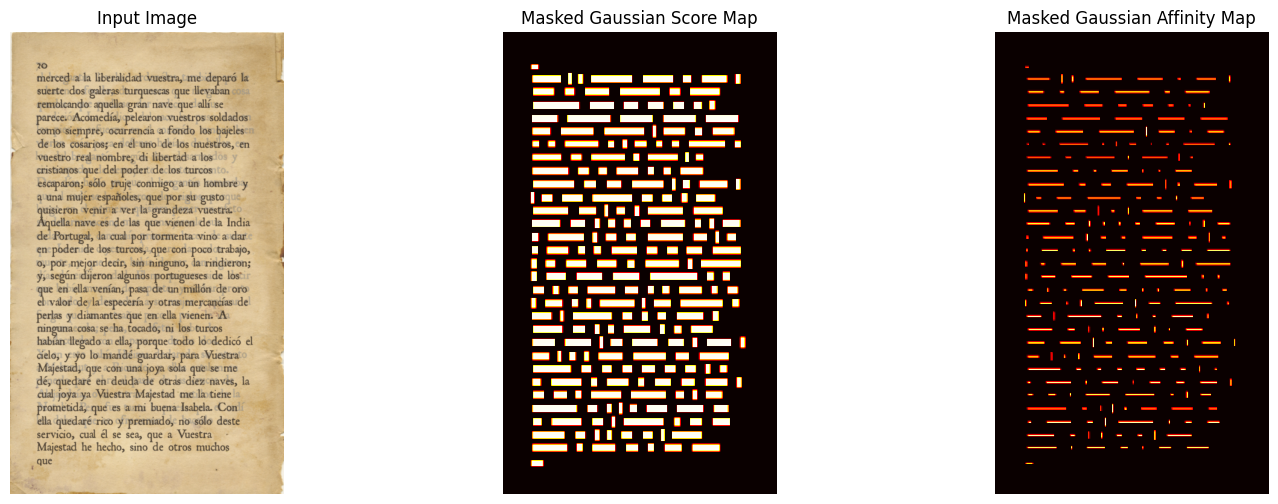

In [5]:
# Preview generated masked Gaussian maps for a random sample
import random
idx = random.randint(0, len(dataset)-1)
sample = dataset[idx]
image_tensor = sample['image']
score_map = sample['targets'][0].numpy()
affinity_map = sample['targets'][1].numpy()

# Convert tensor to PIL image for display
image = transforms.ToPILImage()(image_tensor)

import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(image)
axs[0].set_title('Input Image')
axs[0].axis('off')
axs[1].imshow(score_map, cmap='hot')
axs[1].set_title('Masked Gaussian Score Map')
axs[1].axis('off')
axs[2].imshow(affinity_map, cmap='hot')
axs[2].set_title('Masked Gaussian Affinity Map')
axs[2].axis('off')
plt.show()


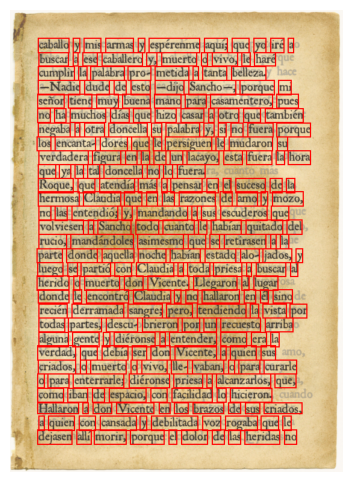

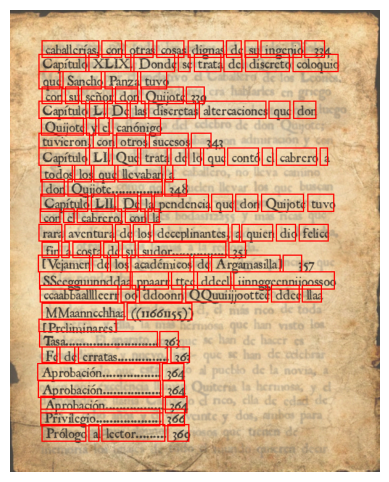

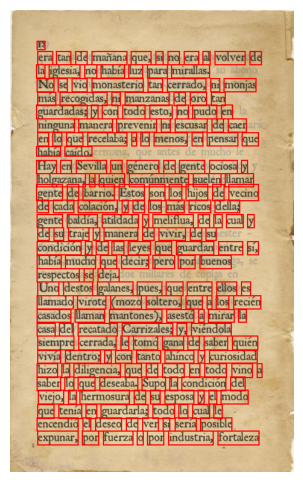

In [5]:
# Visualize a few samples with bounding boxes (draws directly on resized image with already-scaled bboxes)
def plot_sample(dataset, idx):
    sample = dataset[idx]
    image_tensor = sample['image']
    bboxes = sample['bboxes']
    # Convert tensor to PIL image for display
    image = transforms.ToPILImage()(image_tensor)
    draw = ImageDraw.Draw(image)
    for box in bboxes:
        if len(box) == 4:
            x1, y1, x2, y2 = box
            quad = [
                (x1, y1),
                (x2, y1),
                (x2, y2),
                (x1, y2)
            ]
        elif len(box) == 8:
            quad = [(box[i], box[i+1]) for i in range(0, 8, 2)]
        else:
            continue
        draw.polygon(quad, outline='red', width=2)
    plt.figure(figsize=(10,6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Show 3 random samples
import random
for i in random.sample(range(len(dataset)), min(3, len(dataset))):
    plot_sample(dataset, i)


## 5. Prepare DataLoader for Training
Create PyTorch DataLoader objects for training and validation splits to efficiently batch and shuffle data.

In [6]:
import torch
from torch.utils.data import DataLoader, random_split

# Split dataset into train and validation
val_split = 0.1
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# DataLoader settings for better GPU utilization
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Using device: cuda
Train samples: 2748, Validation samples: 305


## 6. Modify CRAFT Model for Custom Training
Load the pre-trained CRAFT model and modify it if necessary for finetuning. Freeze or unfreeze layers as required.

In [ ]:
# Load pre-trained CRAFT model and prepare for finetuning
from craft import CRAFT
from collections import OrderedDict

# Path to pre-trained weights (update if needed)
pretrained_weights = 'CRAFT-pytorch/weights/craft_mlt_25k.pth'

model = CRAFT()
# Robustly load weights, handling 'module.' prefix and possible state dict nesting
state_dict = torch.load(pretrained_weights, map_location=DEVICE)
if 'state_dict' in state_dict:
    state_dict = state_dict['state_dict']
# Remove 'module.' prefix if present
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace('module.', '')  # remove 'module.' if it exists
    new_state_dict[name] = v
model.load_state_dict(new_state_dict, strict=False)
model = model.to(DEVICE)

# Optionally freeze backbone layers for transfer learning
for param in model.parameters():
    param.requires_grad = True  # Set to False to freeze layers


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## 7. Define Loss Function and Optimizer
Set up the loss function (e.g., CRAFT-specific loss) and optimizer (e.g., Adam or SGD) for training.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CraftLoss(nn.Module):
    """
    CRAFT-style loss:
      - pixel-wise MSE between predicted and GT character region score maps
        and between predicted and GT affinity/link maps.
      - Online Hard Example Mining (OHEM) to select high-loss negative pixels
        so positives/negatives are balanced.
    Expected model outputs:
      y_pred: tensor shape (N, 2, H, W)  -> channels: [region_score, affinity_score]
    Expected targets:
      y_true: tensor shape (N, 2, H, W)  -> same ordering
      training_mask: tensor shape (N, H, W) -> 1 for pixels used in loss, 0 to ignore
    """
    def __init__(self, negative_ratio: float = 3.0, eps: float = 1e-6):
        """
        negative_ratio: desired number of negative pixels per positive pixel when applying OHEM.
                        Typical values in many repros: 3.0
        """
        super().__init__()
        self.negative_ratio = negative_ratio
        self.eps = eps
        self.mse = nn.MSELoss(reduction="none")

    def forward(self, y_pred, y_true, training_mask=None):
        """
        y_pred: (N, 2, H, W) predicted region & affinity maps (float)
        y_true: (N, 2, H, W) ground truth region & affinity maps (float)
        training_mask: (N, H, W) binary mask. If None, all pixels are used.
        Returns: scalar loss
        """
        assert y_pred.shape == y_true.shape, "pred and true must have same shape"
        assert y_pred.dim() == 4 and y_pred.size(1) == 2, "expect channel dim = 2 (region, affinity)"

        # Split channels
        pred_region = y_pred[:, 0, :, :]   # (N, H, W)
        pred_affinity = y_pred[:, 1, :, :]
        true_region = y_true[:, 0, :, :]
        true_affinity = y_true[:, 1, :, :]

        # Default mask -> all ones
        if training_mask is None:
            training_mask = torch.ones_like(true_region, dtype=true_region.dtype, device=true_region.device)

        # Compute per-pixel MSE (no reduction)
        loss_region_map = self.mse(pred_region, true_region)   # (N, H, W)
        loss_affinity_map = self.mse(pred_affinity, true_affinity)  # (N, H, W)

        # Apply training_mask (ignore some pixels)
        loss_region_map = loss_region_map * training_mask
        loss_affinity_map = loss_affinity_map * training_mask

        # For each sample in batch, apply OHEM on negative pixels to balance pos/neg
        def ohem_select(loss_map, gt_map, mask):
            """
            loss_map, gt_map, mask are (H, W) for a single sample.
            Keep:
             - all positive pixel losses (gt_map > 0.0)
             - top-k negative pixel losses (where gt_map == 0) chosen by highest loss,
               where k = pos_count * negative_ratio
            Returns a binary selection mask (H, W) of dtype float (0/1).
            """
            device = loss_map.device
            gt_pos = (gt_map > 0.0).float()
            pos_count = int(gt_pos.sum().item())

            # Negative candidates: where gt==0 and mask==1
            neg_cand_mask = ((gt_map <= 0.0) * (mask > 0.5)).bool()

            # If no positives, fallback: select a small fixed number of negatives
            if pos_count == 0:
                # choose up to 1000 negative pixels or all available
                neg_count = min(1000, int(neg_cand_mask.sum().item()))
            else:
                neg_count = min(int(self.negative_ratio * pos_count), int(neg_cand_mask.sum().item()))

            # Build selection mask
            sel_mask = torch.zeros_like(loss_map, dtype=torch.float32, device=device)
            # keep positives
            sel_mask = sel_mask + gt_pos

            if neg_count > 0:
                # take top-k negative losses
                neg_losses = loss_map.clone()
                neg_losses[~neg_cand_mask] = -1.0  # exclude non-candidates
                # flatten and select topk
                flat = neg_losses.view(-1)
                # If there are fewer than neg_count valid negatives, topk will error -> handle
                valid = (flat >= 0)
                valid_count = int(valid.sum().item())
                if valid_count > 0:
                    k = min(neg_count, valid_count)
                    if k > 0:
                        topk_vals, topk_idx = torch.topk(flat, k)
                        sel_mask.view(-1)[topk_idx] = 1.0
            # Ensure we only select inside training_mask (mask)
            sel_mask = sel_mask * (mask > 0.5).float()
            return sel_mask

        N = y_pred.size(0)
        loss_region_total = 0.0
        loss_affinity_total = 0.0
        eps = self.eps

        for i in range(N):
            lr_map = loss_region_map[i]     # (H,W)
            la_map = loss_affinity_map[i]
            gt_r = true_region[i]
            gt_a = true_affinity[i]
            m = training_mask[i]

            sel_r = ohem_select(lr_map, gt_r, m)
            sel_a = ohem_select(la_map, gt_a, m)

            # Avoid division by zero: normalize by number of selected pixels
            r_sel_sum = sel_r.sum()
            a_sel_sum = sel_a.sum()

            if r_sel_sum.item() > 0:
                loss_region_total += (lr_map * sel_r).sum() / (r_sel_sum + eps)
            # else add 0
            if a_sel_sum.item() > 0:
                loss_affinity_total += (la_map * sel_a).sum() / (a_sel_sum + eps)

        # Average over batch
        loss_region_total = loss_region_total / float(N)
        loss_affinity_total = loss_affinity_total / float(N)

        # Final loss: equal weighting (matching many re-implementations). You can tune weights if desired.
        loss = loss_region_total + loss_affinity_total
        return loss


In [9]:
# replace previous placeholder
loss_fn = CraftLoss(negative_ratio=3.0)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 8. Train the CRAFT Model
Implement the training loop, including forward pass, loss computation, backward pass, and optimizer step. Track training loss and metrics.

In [10]:
# Training loop with ASCII progress bar, validation tracking, and early stopping
from tqdm import tqdm
import matplotlib.pyplot as plt
from copy import deepcopy

loss_history = []
val_loss_history = []

patience = 8
best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_state = None
best_epoch = -1

has_validation = len(val_loader.dataset) > 0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    train_loader_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True)
    for batch in train_loader_iter:
        images = batch['image'].to(DEVICE)
        targets = batch['targets'].to(DEVICE)  # (B, 2, H, W)
        y, _ = model(images)
        y = y.permute(0, 3, 1, 2)  # (B, 2, H, W)
        optimizer.zero_grad()
        loss = loss_fn(y, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        train_loader_iter.set_postfix(loss=loss.item())
    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)

    val_epoch_loss = None
    if has_validation:
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(DEVICE)
                targets = batch['targets'].to(DEVICE)
                y_val, _ = model(images)
                y_val = y_val.permute(0, 3, 1, 2)
                val_loss = loss_fn(y_val, targets)
                val_running_loss += val_loss.item() * images.size(0)
        if len(val_loader.dataset) > 0:
            val_epoch_loss = val_running_loss / len(val_loader.dataset)
            val_loss_history.append(val_epoch_loss)

    if val_epoch_loss is not None:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
        if val_epoch_loss < best_val_loss - 1e-6:
            best_val_loss = val_epoch_loss
            epochs_without_improvement = 0
            best_model_state = deepcopy(model.state_dict())
            best_epoch = epoch
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f} (epoch {best_epoch+1}).")
                break
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model from epoch {best_epoch+1} with val loss {best_val_loss:.4f}.")
elif has_validation and len(val_loss_history) == 0:
    print("Validation loader was empty; training completed without early stopping.")

print("Training complete.")

Epoch 1/100: 100%|██████████| 2748/2748 [15:00<00:00,  3.05it/s, loss=0.141] 


Epoch 1/100, Loss: 0.0453, Val Loss: 0.0984


Epoch 2/100: 100%|██████████| 2748/2748 [13:21<00:00,  3.43it/s, loss=0.0172]


Epoch 2/100, Loss: 0.0293, Val Loss: 0.1105


Epoch 3/100: 100%|██████████| 2748/2748 [13:25<00:00,  3.41it/s, loss=0.0194] 


...

Epoch 9/100, Loss: 0.0156, Val Loss: 0.1019


Epoch 10/100: 100%|██████████| 2748/2748 [13:13<00:00,  3.46it/s, loss=0.0816] 


Epoch 10/100, Loss: 0.0149, Val Loss: 0.1014


Epoch 11/100: 100%|██████████| 2748/2748 [13:12<00:00,  3.47it/s, loss=0.0143] 


Epoch 11/100, Loss: 0.0140, Val Loss: 0.1021
Early stopping triggered at epoch 11. Best Val Loss: 0.0952 (epoch 3).
Restored best model from epoch 3 with val loss 0.0952.
Training complete.


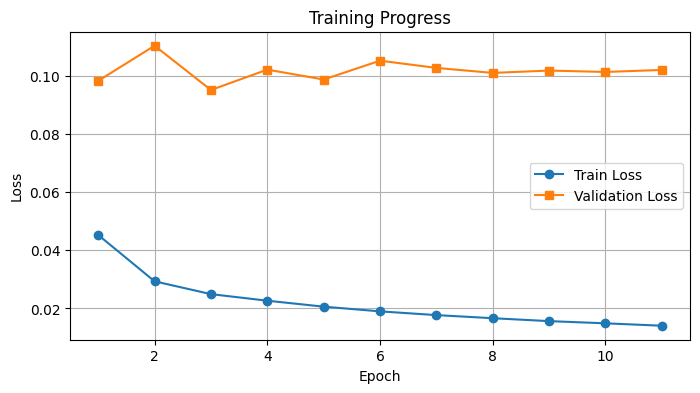

In [11]:
# Plot training and validation loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', label='Train Loss')
if val_loss_history:
    plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.grid(True)
if val_loss_history:
    plt.legend()
plt.show()

## 9. Evaluate Model on Validation Set
Run the trained model on the validation set to compute evaluation metrics and visualize predictions.

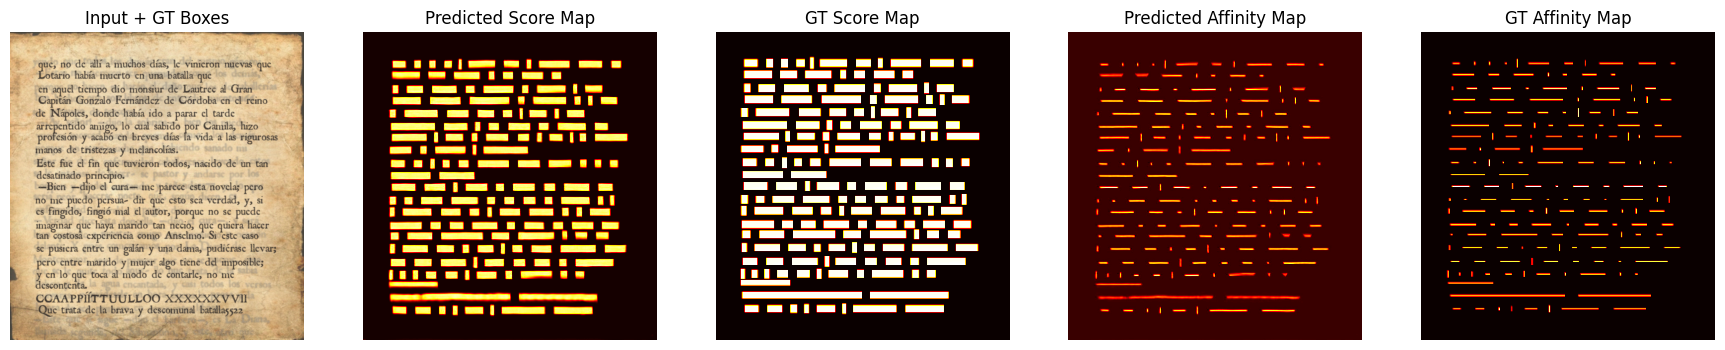

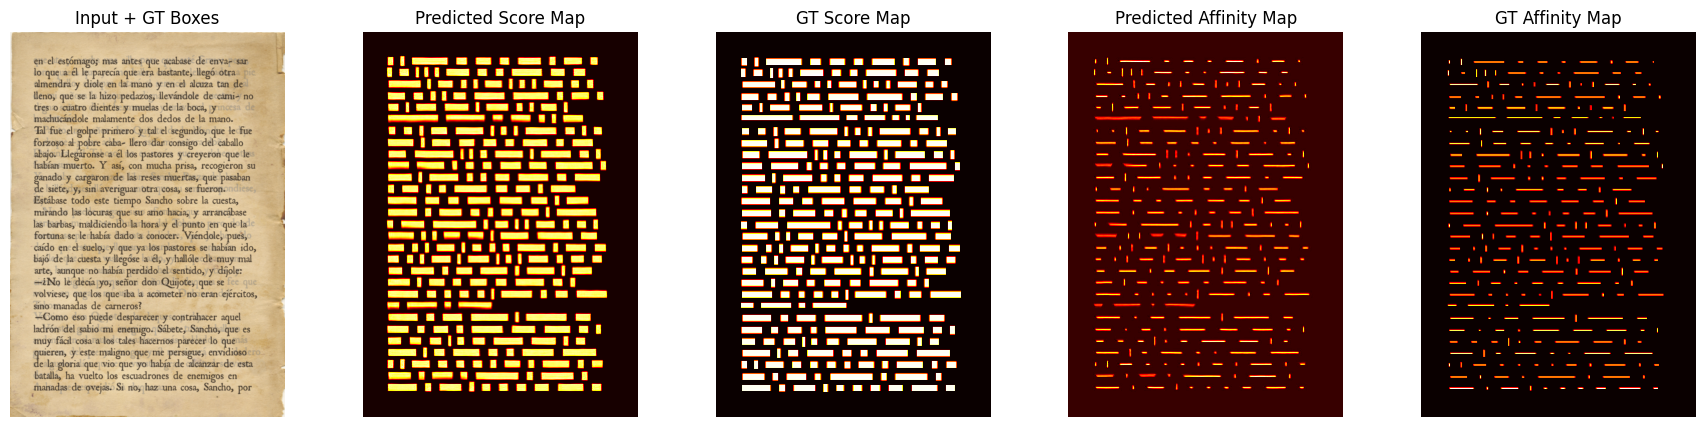

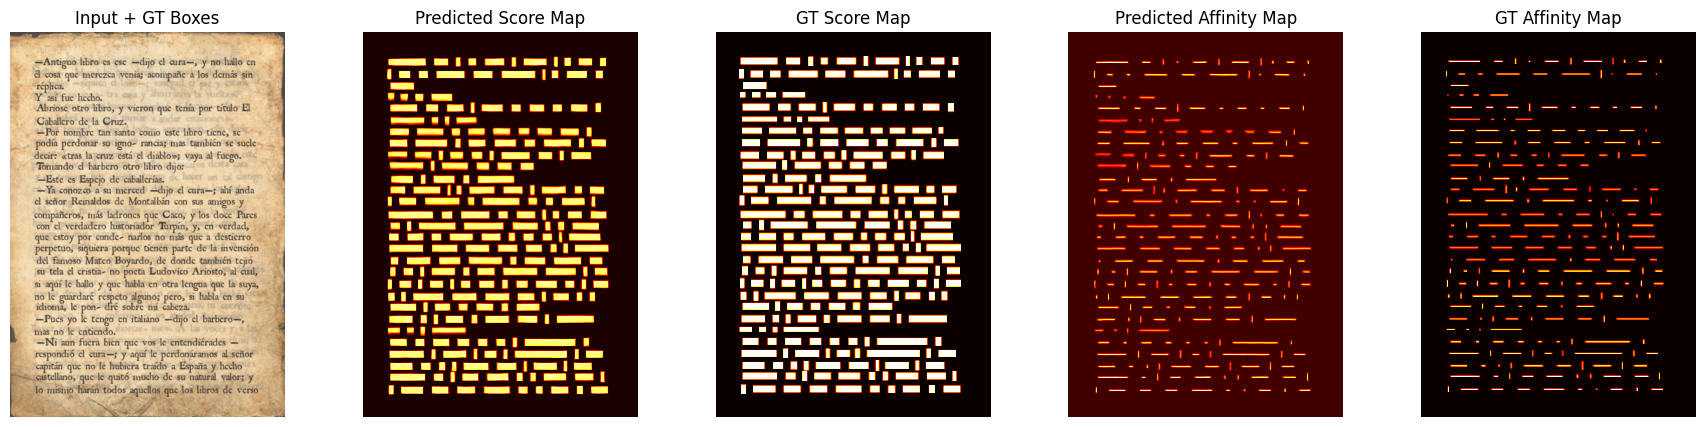

In [12]:
# Evaluate on validation set (compare input, predicted/GT score & affinity maps, and GT boxes)
model.eval()
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        images = batch['image'].to(DEVICE)
        bboxes_batch = batch['bboxes']
        targets = batch['targets']  # (B, 2, H, W)
        y_pred, _ = model(images)
        y_pred = y_pred.cpu().numpy()  # (B, H, W, 2)
        targets = targets.cpu().numpy()  # (B, 2, H, W)
        for j in range(images.size(0)):
            img = images[j].cpu()
            bboxes = bboxes_batch[j]
            # Convert tensor to PIL image for display
            pil_img = transforms.ToPILImage()(img)
            draw = ImageDraw.Draw(pil_img)
            for box in bboxes:
                if len(box) == 4:
                    x1, y1, x2, y2 = box
                    quad = [
                        (x1, y1),
                        (x2, y1),
                        (x2, y2),
                        (x1, y2)
                    ]
                elif len(box) == 8:
                    quad = [(box[k], box[k+1]) for k in range(0, 8, 2)]
                else:
                    continue
                draw.polygon(quad, outline='red', width=2)
            # Get predicted and GT score/affinity maps
            score_map_pred = y_pred[j][...,0]
            affinity_map_pred = y_pred[j][...,1]
            score_map_gt = targets[j][0]
            affinity_map_gt = targets[j][1]
            # Show all
            fig, axs = plt.subplots(1, 5, figsize=(22, 5))
            axs[0].imshow(pil_img)
            axs[0].set_title('Input + GT Boxes')
            axs[0].axis('off')
            axs[1].imshow(score_map_pred, cmap='hot')
            axs[1].set_title('Predicted Score Map')
            axs[1].axis('off')
            axs[2].imshow(score_map_gt, cmap='hot')
            axs[2].set_title('GT Score Map')
            axs[2].axis('off')
            axs[3].imshow(affinity_map_pred, cmap='hot')
            axs[3].set_title('Predicted Affinity Map')
            axs[3].axis('off')
            axs[4].imshow(affinity_map_gt, cmap='hot')
            axs[4].set_title('GT Affinity Map')
            axs[4].axis('off')
            plt.show()
        if i >= 2:
            break  # Show only a few batches


## 10. Save Trained Model Checkpoints
Save the trained model weights and checkpoints for future inference or further finetuning.

In [13]:
# Save the trained model
save_path = os.path.join(OUTPUT_DIR, 'craft_finetuned.pth')
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to output_craft_finetune/craft_finetuned.pth


## 11. Compare Performance: Pretrained vs. Finetuned Model

In this section, we compare the detection results of the original pretrained CRAFT model and your finetuned model on a few validation images. This helps visualize the improvements from finetuning on your custom dataset.

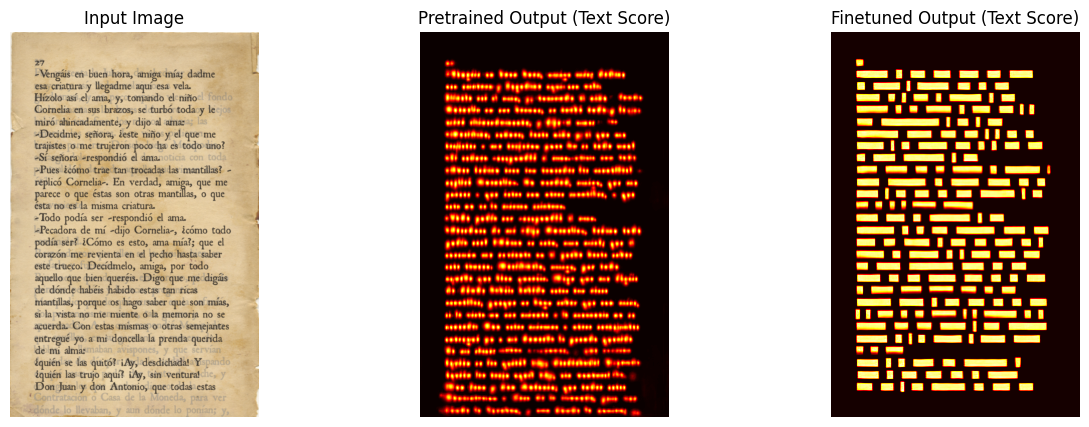

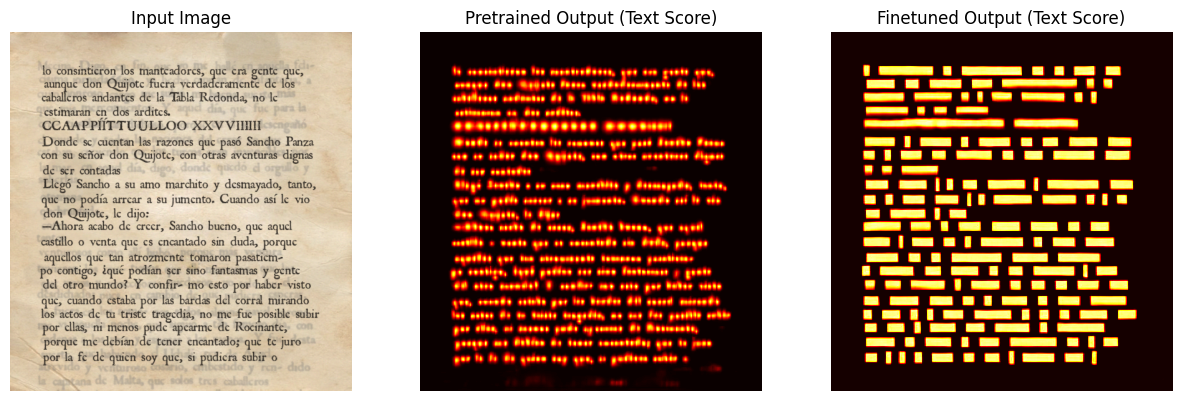

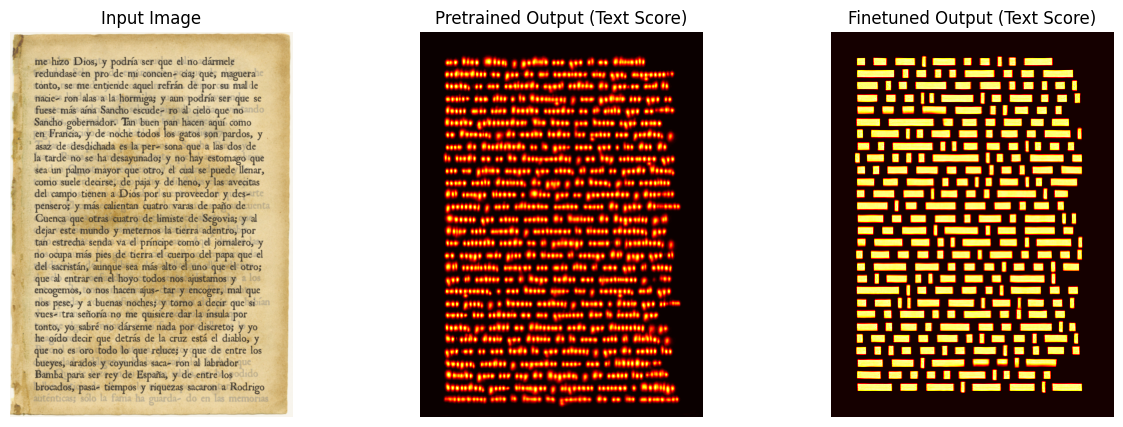

In [ ]:
# Compare performance of pretrained and finetuned CRAFT models
from craft import CRAFT
from collections import OrderedDict

# Load pretrained model
pretrained_model = CRAFT()
pretrained_weights = 'CRAFT-pytorch/weights/craft_mlt_25k.pth'
state_dict = torch.load(pretrained_weights, map_location=DEVICE)
if 'state_dict' in state_dict:
    state_dict = state_dict['state_dict']
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace('module.', '')
    new_state_dict[name] = v
pretrained_model.load_state_dict(new_state_dict, strict=False)
pretrained_model = pretrained_model.to(DEVICE)
pretrained_model.eval()

# Load finetuned model
finetuned_model = CRAFT()
finetuned_weights = os.path.join(OUTPUT_DIR, 'craft_finetuned.pth')
finetuned_model.load_state_dict(torch.load(finetuned_weights, map_location=DEVICE), strict=False)
finetuned_model = finetuned_model.to(DEVICE)
finetuned_model.eval()

# Visualize predictions from both models on a few validation images
num_samples = 3
import random
indices = random.sample(range(len(val_dataset)), min(num_samples, len(val_dataset)))

for idx in indices:
    sample = val_dataset[idx]
    image = sample['image']
    if isinstance(image, torch.Tensor):
        image = image.unsqueeze(0).to(DEVICE)
    else:
        image = transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        y_pre, _ = pretrained_model(image)
        y_fine, _ = finetuned_model(image)
    # Convert outputs to numpy for visualization
    y_pre_np = y_pre[0].cpu().numpy()
    y_fine_np = y_fine[0].cpu().numpy()
    # Show side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(transforms.ToPILImage()(sample['image'].cpu() if isinstance(sample['image'], torch.Tensor) else sample['image']))
    axs[0].set_title('Input Image')
    axs[0].axis('off')
    axs[1].imshow(y_pre_np[...,0], cmap='hot')
    axs[1].set_title('Pretrained Output (Text Score)')
    axs[1].axis('off')
    axs[2].imshow(y_fine_np[...,0], cmap='hot')
    axs[2].set_title('Finetuned Output (Text Score)')
    axs[2].axis('off')
    plt.show()

## 12. Compare Bounding Boxes: Pretrained vs. Finetuned Model

This section runs the CRAFT `test.py` script on 3 random images using both the pretrained and your finetuned model, then visualizes the bounding boxes side by side for direct comparison.

In [ ]:
import os
import random
import shutil
import matplotlib.pyplot as plt
from PIL import Image

# --- Replace selection-from-DATA_DIR with selection-from-val_loader ----
import torch
import torchvision
from torchvision.transforms import ToPILImage

import os
import random
import shutil

def get_val_samples_from_loader_simple(val_loader, sample_dir, num_samples=3):
    """
    Sample images from val_loader.dataset (CraftDataset) and save them to sample_dir.
    """
    os.makedirs(sample_dir, exist_ok=True)
    dataset = val_loader.dataset

    # If using random_split, dataset is a Subset, so get the underlying dataset
    if isinstance(dataset, torch.utils.data.Subset):
        subset_indices = dataset.indices
        dataset = dataset.dataset
    else:
        subset_indices = list(range(len(dataset)))

    # Sample indices from validation subset
    sampled_indices = random.sample(subset_indices, min(num_samples, len(subset_indices)))
    saved_files = []

    for idx in sampled_indices:
        img_name = dataset.img_files[idx]
        src_path = os.path.join(dataset.img_dir, img_name)
        dst_path = os.path.join(sample_dir, img_name)
        shutil.copy(src_path, dst_path)
        saved_files.append(img_name)

    return saved_files

# Usage
NUM_SAMPLES = 10
sample_dir = "sample_compare_imgs"
sample_imgs = get_val_samples_from_loader_simple(val_loader, sample_dir, num_samples=NUM_SAMPLES)
print("Saved sample images:", sample_imgs)

PRETRAINED_MODEL = os.path.join('CRAFT-pytorch', 'weights', 'craft_mlt_25k.pth')
FINETUNED_MODEL = os.path.join(OUTPUT_DIR, 'craft_finetuned.pth')
os.makedirs(sample_dir, exist_ok=True)
for img in sample_imgs:
    shutil.copy(os.path.join(DATA_DIR, img), os.path.join(sample_dir, img))

# Output folders
out_pretrained = 'output_pretrained_compare//'
out_finetuned = 'output_finetuned_compare//'

# Run test.py for both models
import subprocess
def text_detection(input_root, output_root, model_path):
    print(f"Generating bounding boxes in {output_root}...")
    os.makedirs(output_root, exist_ok=True)
    command = (
        f"python CRAFT-pytorch/test.py "
        f"--trained_model={model_path} "
        f"--result_folder={output_root} "
        f"--test_folder={input_root}"
    )
    subprocess.run(command, shell=True, check=True)

# Run for pretrained and finetuned
text_detection(sample_dir, out_pretrained, PRETRAINED_MODEL)
text_detection(sample_dir, out_finetuned, FINETUNED_MODEL)

Saved sample images: ['page_205.png', 'page_1802.png', 'page_499.png', 'page_472.png', 'page_2062.png', 'page_2436.png', 'page_1683.png', 'page_2627.png', 'page_2043.png', 'page_1889.png']
Generating bounding boxes in output_pretrained_compare//...
Generating bounding boxes in output_finetuned_compare//...


In [ ]:
# Helper to plot results side by side
def plot_results_side_by_side(img_names, out1, out2, title1, title2):
    from PIL import ImageDraw

    def load_with_boxes(img_path, txt_path, color):
        img = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        if os.path.exists(txt_path):
            with open(txt_path, "r") as f:
                for line in f:
                    parts = line.strip().split(",")
                    if len(parts) >= 8:  # x1,y1,...,x4,y4
                        pts = [(float(parts[i]), float(parts[i+1])) for i in range(0, 8, 2)]
                        draw.polygon(pts, outline=color, width=2)
        return img

    for img_name in img_names:
        img_path = os.path.join(sample_dir, img_name)
        base = os.path.splitext(img_name)[0]

        # Corresponding text outputs (not _result.jpg anymore)
        res1_txt = os.path.join(out1, base + ".txt")
        res2_txt = os.path.join(out2, base + ".txt")

        # Overlay boxes
        im1 = load_with_boxes(img_path, res1_txt, (255, 0, 0))
        im2 = load_with_boxes(img_path, res2_txt, (0, 0, 255))

        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        axs[0].imshow(Image.open(img_path))
        axs[0].set_title("Input")
        axs[0].axis("off")
        axs[1].imshow(im1)
        axs[1].set_title(title1)
        axs[1].axis("off")
        axs[2].imshow(im2)
        axs[2].set_title(title2)
        axs[2].axis("off")
        plt.suptitle(f"Bounding Box Comparison: {img_name}")
        plt.show()


plot_results_side_by_side(sample_imgs, out_pretrained, out_finetuned, 'Pretrained', 'Finetuned')